In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as scop
import csv
import matplotlib as mpl

#LOADING FUNCTION
def load_magnetisation_data(file_location, 
                            cgs_or_si="cgs", 
                            temp_range=(0, 300)):
    """
    Load, sanitise, and optionally convert magnetisation data 
    from a PPMS datafile (Quantum Design format).

    Parameters
    ----------
    file_location : str
        Directory where the data file is stored.
    cgs_or_si : str, default "cgs"
        Choose "cgs" to keep raw PPMS units or "si" for SI conversion.
    temp_range : tuple, default (0, 300)
        Lower and upper bounds for temperature filtering (K).

    Returns
    -------
    df : pd.DataFrame
        Sanitised dataframe in chosen units and restricted to the temperature range.
    headers_line : int
        Index where headers started in the original file.
    """
    FILEANDPATH = file_location

    # Find where headers start (due to PPMS metadata junk at top of file)
    index_of_headers = 0
    for i in range(100):
        try:
            _ = pd.read_csv(FILEANDPATH, sep=",", skiprows=i, encoding="unicode_escape")
            index_of_headers = i + 1  # need +1 for correct parsing
            break
        except Exception:
            continue

    # Load dataframe properly
    df_raw = pd.read_csv(FILEANDPATH, sep=",", skiprows=index_of_headers, encoding="unicode_escape")

    # Drop columns with all NaNs
    df_clean = df_raw.dropna(axis=1, how="all")

    # Convert to SI if requested
    if cgs_or_si.lower() == "cgs":
        df_final = df_clean.copy()
    elif cgs_or_si.lower() == "si":
        df_final = df_clean.copy()
        df_final["Magnetic Field (Oe)"] *= 0.0001
        df_final["Moment (emu)"] *= 1e-3
        df_final.rename(columns={
            "Magnetic Field (Oe)": "Magnetic Field (T)",
            "Moment (emu)": "Moment (Am^2)"
        }, inplace=True)
    else:
        raise ValueError("cgs_or_si must be either 'cgs' or 'si'")

    # Apply temperature range filter
    lower_temp, higher_temp = temp_range
    df_final = df_final[(df_final["Temperature (K)"] >= lower_temp) & 
                        (df_final["Temperature (K)"] <= higher_temp)]

    print(f"Headers found at line {index_of_headers}")
    #print(f"Remaining Column Headers: {df_final.columns}")

    return df_final, index_of_headers

#SAVE PLOT FUNCTION
import os
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt

def save_next_plot(folder, prefix="graph", ext="png", fig=None):
    """
    Save the current matplotlib figure into 'folder' with auto-increment filename.
    
    Parameters
    ----------
    folder : str
        Path to the folder where plots will be saved.
    prefix : str, default 'graph'
        Filename prefix, e.g. 'graph' -> graph_001.png
    ext : str, default 'png'
        File extension, e.g. 'png', 'pdf', 'svg'.
    fig : matplotlib.figure.Figure, optional
        Figure to save. Defaults to current figure.
        
    Returns
    -------
    str
        Full path of the saved file.
    """
    os.makedirs(folder, exist_ok=True)
    
    existing = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith("." + ext)]
    numbers = []
    for f in existing:
        try:
            num = int(f.replace(prefix + "_", "").replace("." + ext, ""))
            numbers.append(num)
        except ValueError:
            continue
    
    next_num = max(numbers) + 1 if numbers else 1
    filename = f"{prefix}_{next_num:03d}.{ext}"
    fullpath = os.path.join(folder, filename)
    
    if fig is None:
        fig = plt.gcf()
    
    fig.savefig(fullpath, dpi=300, bbox_inches="tight")
    print(f"Plot saved as: {fullpath}")
    
    return fullpath



#examples of loading data
'''
df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="si",
    temp_range=(2, 100)
)
df_mag2, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag2,
    cgs_or_si="si",
    temp_range=(2, 100)
)
'''

'\ndf_mag1, header_line = load_magnetisation_data(\n    file_location=FILEANDPATHMag1,\n    cgs_or_si="si",\n    temp_range=(2, 100)\n)\ndf_mag2, header_line = load_magnetisation_data(\n    file_location=FILEANDPATHMag2,\n    cgs_or_si="si",\n    temp_range=(2, 100)\n)\n'

Headers found at line 30
Headers found at line 30
Headers found at line 30
x2 length: 4875
y2 length: 4875
finite y2: 4875
===== Curie–Weiss Fit (ZFC) =====
C      = 2.5293 ± 0.0119 emu K mol^-1 Oe^-1
μ_eff  = 4.498 ± 0.011 μB
θ      = -64.11 ± 0.65 K
χ₀     = -0.000275 ± 0.000021 emu mol^-1 Oe^-1


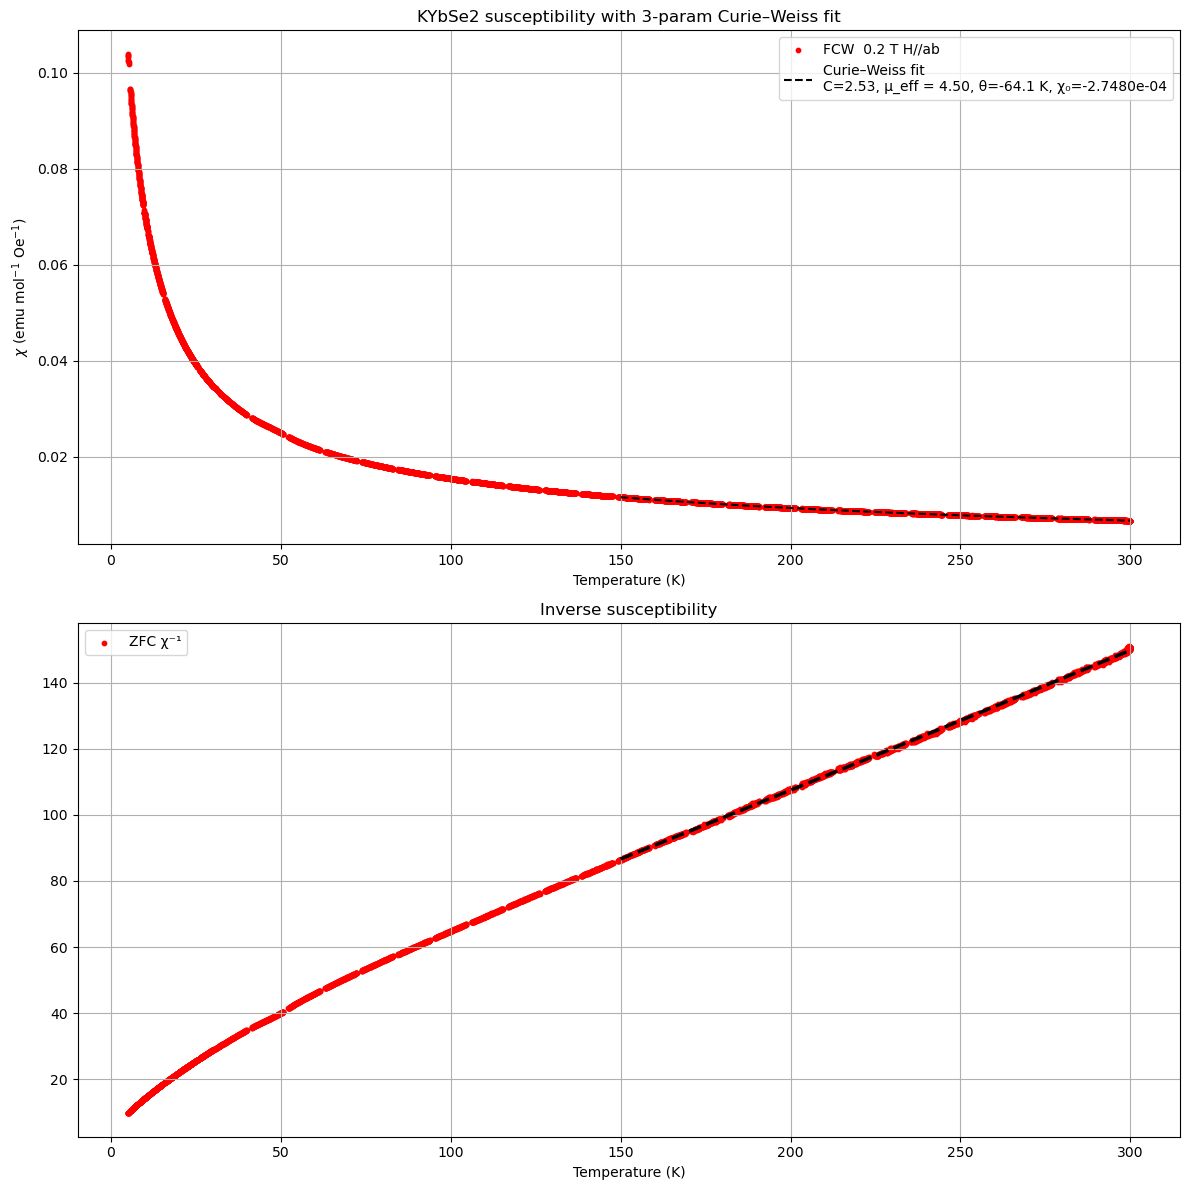

In [32]:
#SUSCEPTIBILITY AND CURIE-WEISS FITTING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

'''
# -----------------------------
# Load reference (Namba) data
# -----------------------------
df_ref = pd.read_csv(
    "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/RuCl3/Data/Magnetisation/Namba_raw_data.csv",
    sep=",", encoding="unicode_escape"
)

x1 = df_ref['x']
y1 = df_ref[' y']   # already emu/mol (not scaled)
'''

# -----------------------------
# Load your data
# -----------------------------
#Filepath where the point the test datafile exists in so it can be accessed
'''MAGNETISATION DATA'''
filepath = "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/KYbSe2/Magnetisation/"
file1 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_FCC_300TO30K.dat"
FILEANDPATHMag1=filepath+file1





file1 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_5KTO30K.dat"
file2 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_30K_TO300K.dat"

FILE1 = filepath + file1
FILE2 = filepath + file2

# -----------------------------
# Load datasets for stitching together 5 to 30 k and 30 to 300 K
# -----------------------------
df1, header1 = load_magnetisation_data(
    file_location=FILE1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

df2, header2 = load_magnetisation_data(
    file_location=FILE2,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

# -----------------------------
# Stitch datasets together
# -----------------------------
df = pd.concat([df1, df2], ignore_index=True)

# -----------------------------
# Clean + sort (important for physics plots)
# -----------------------------
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Temperature (K)", "Moment (emu)"])

df = df.sort_values("Temperature (K)").reset_index(drop=True)

# -----------------------------
# Extract variables
# -----------------------------
x2 = df["Temperature (K)"]
M = df["Moment (emu)"]
H = df["Magnetic Field (Oe)"]


df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

# -----------------------------
# Conversion Factor
# -----------------------------
sample_mass = 0.0049  # g
molar_mass = 370.0853 # g/mol
H = df["Magnetic Field (Oe)"]

chi = M / H
y2 = chi * molar_mass / sample_mass
print("x2 length:", len(x2))
print("y2 length:", len(y2))
print("finite y2:", np.isfinite(y2).sum())

# -----------------------------
# Define 3-parameter Curie–Weiss
# -----------------------------
def curie_weiss_3param(T, C, theta, chi0):
    return C / (T - theta) + chi0

# -----------------------------
# Fit ZFC curve (example)
# -----------------------------
mask = (x2 > 150) & (x2 < 300)   # fitting window
x_fit = x2[mask]
y_fit = y2[mask]

valid = np.isfinite(x_fit) & np.isfinite(y_fit)
x_fit = x_fit[valid]
y_fit = y_fit[valid]

popt, pcov = curve_fit(curie_weiss_3param, x_fit, y_fit,
                    p0=[0.5, 30, -0.0])  # guesses: C, theta, chi0

C_fit, theta_fit, chi0_fit = popt
perr = np.sqrt(np.diag(pcov))

# assuming C_fit and perr[0] (its 1σ) are from a fit done in emu/mol
# if you used a plotting scale_factor (e.g. 1000), DO NOT apply it here.
C_true = C_fit
dC = perr[0]

mu_eff = 2.828 * np.sqrt(C_true)                 # μB / f.u.
mu_eff_err = 2.828 * 0.5 / np.sqrt(C_true) * dC  # error propagation



print("===== Curie–Weiss Fit (ZFC) =====")
print(f"C      = {C_fit:.4f} ± {perr[0]:.4f} emu K mol^-1 Oe^-1")
print(f"μ_eff  = {mu_eff:.3f} ± {mu_eff_err:.3f} μB")
print(f"θ      = {theta_fit:.2f} ± {perr[1]:.2f} K")
print(f"χ₀     = {chi0_fit:.6f} ± {perr[2]:.6f} emu mol^-1 Oe^-1")

# -----------------------------
# Plot χ(T) with fit
# -----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- χ(T)

ax1.scatter(x2, y2, s=10, color='r', label="FCW  0.2 T H//ab")


T_smooth = np.linspace(min(x_fit), max(x_fit), 500)
ax1.plot(T_smooth, curie_weiss_3param(T_smooth, *popt), 'k--',
        label=f"Curie–Weiss fit\nC={C_fit:.2f}, μ_eff = {mu_eff:.2f}, θ={theta_fit:.1f} K, χ₀={chi0_fit:.4e}")

ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax1.set_title("KYbSe2 susceptibility with 3-param Curie–Weiss fit")
ax1.grid(True)
ax1.legend()

# --- χ⁻¹(T)
inv_y2 = 1.0 / y2

ax2.scatter(x2, inv_y2, s=10, color='r', label="ZFC χ⁻¹")


# For comparison, plot inverse of fit
inv_fit = 1.0 / curie_weiss_3param(T_smooth, *popt)
ax2.plot(T_smooth, inv_fit, 'k--', linewidth=2.5)

ax2.set_xlabel("Temperature (K)")
#ax2.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax2.set_title("Inverse susceptibility")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Headers found at line 30
Headers found at line 30
Headers found at line 30
x2 length: 4875
y2 length: 4875
finite y2: 4875


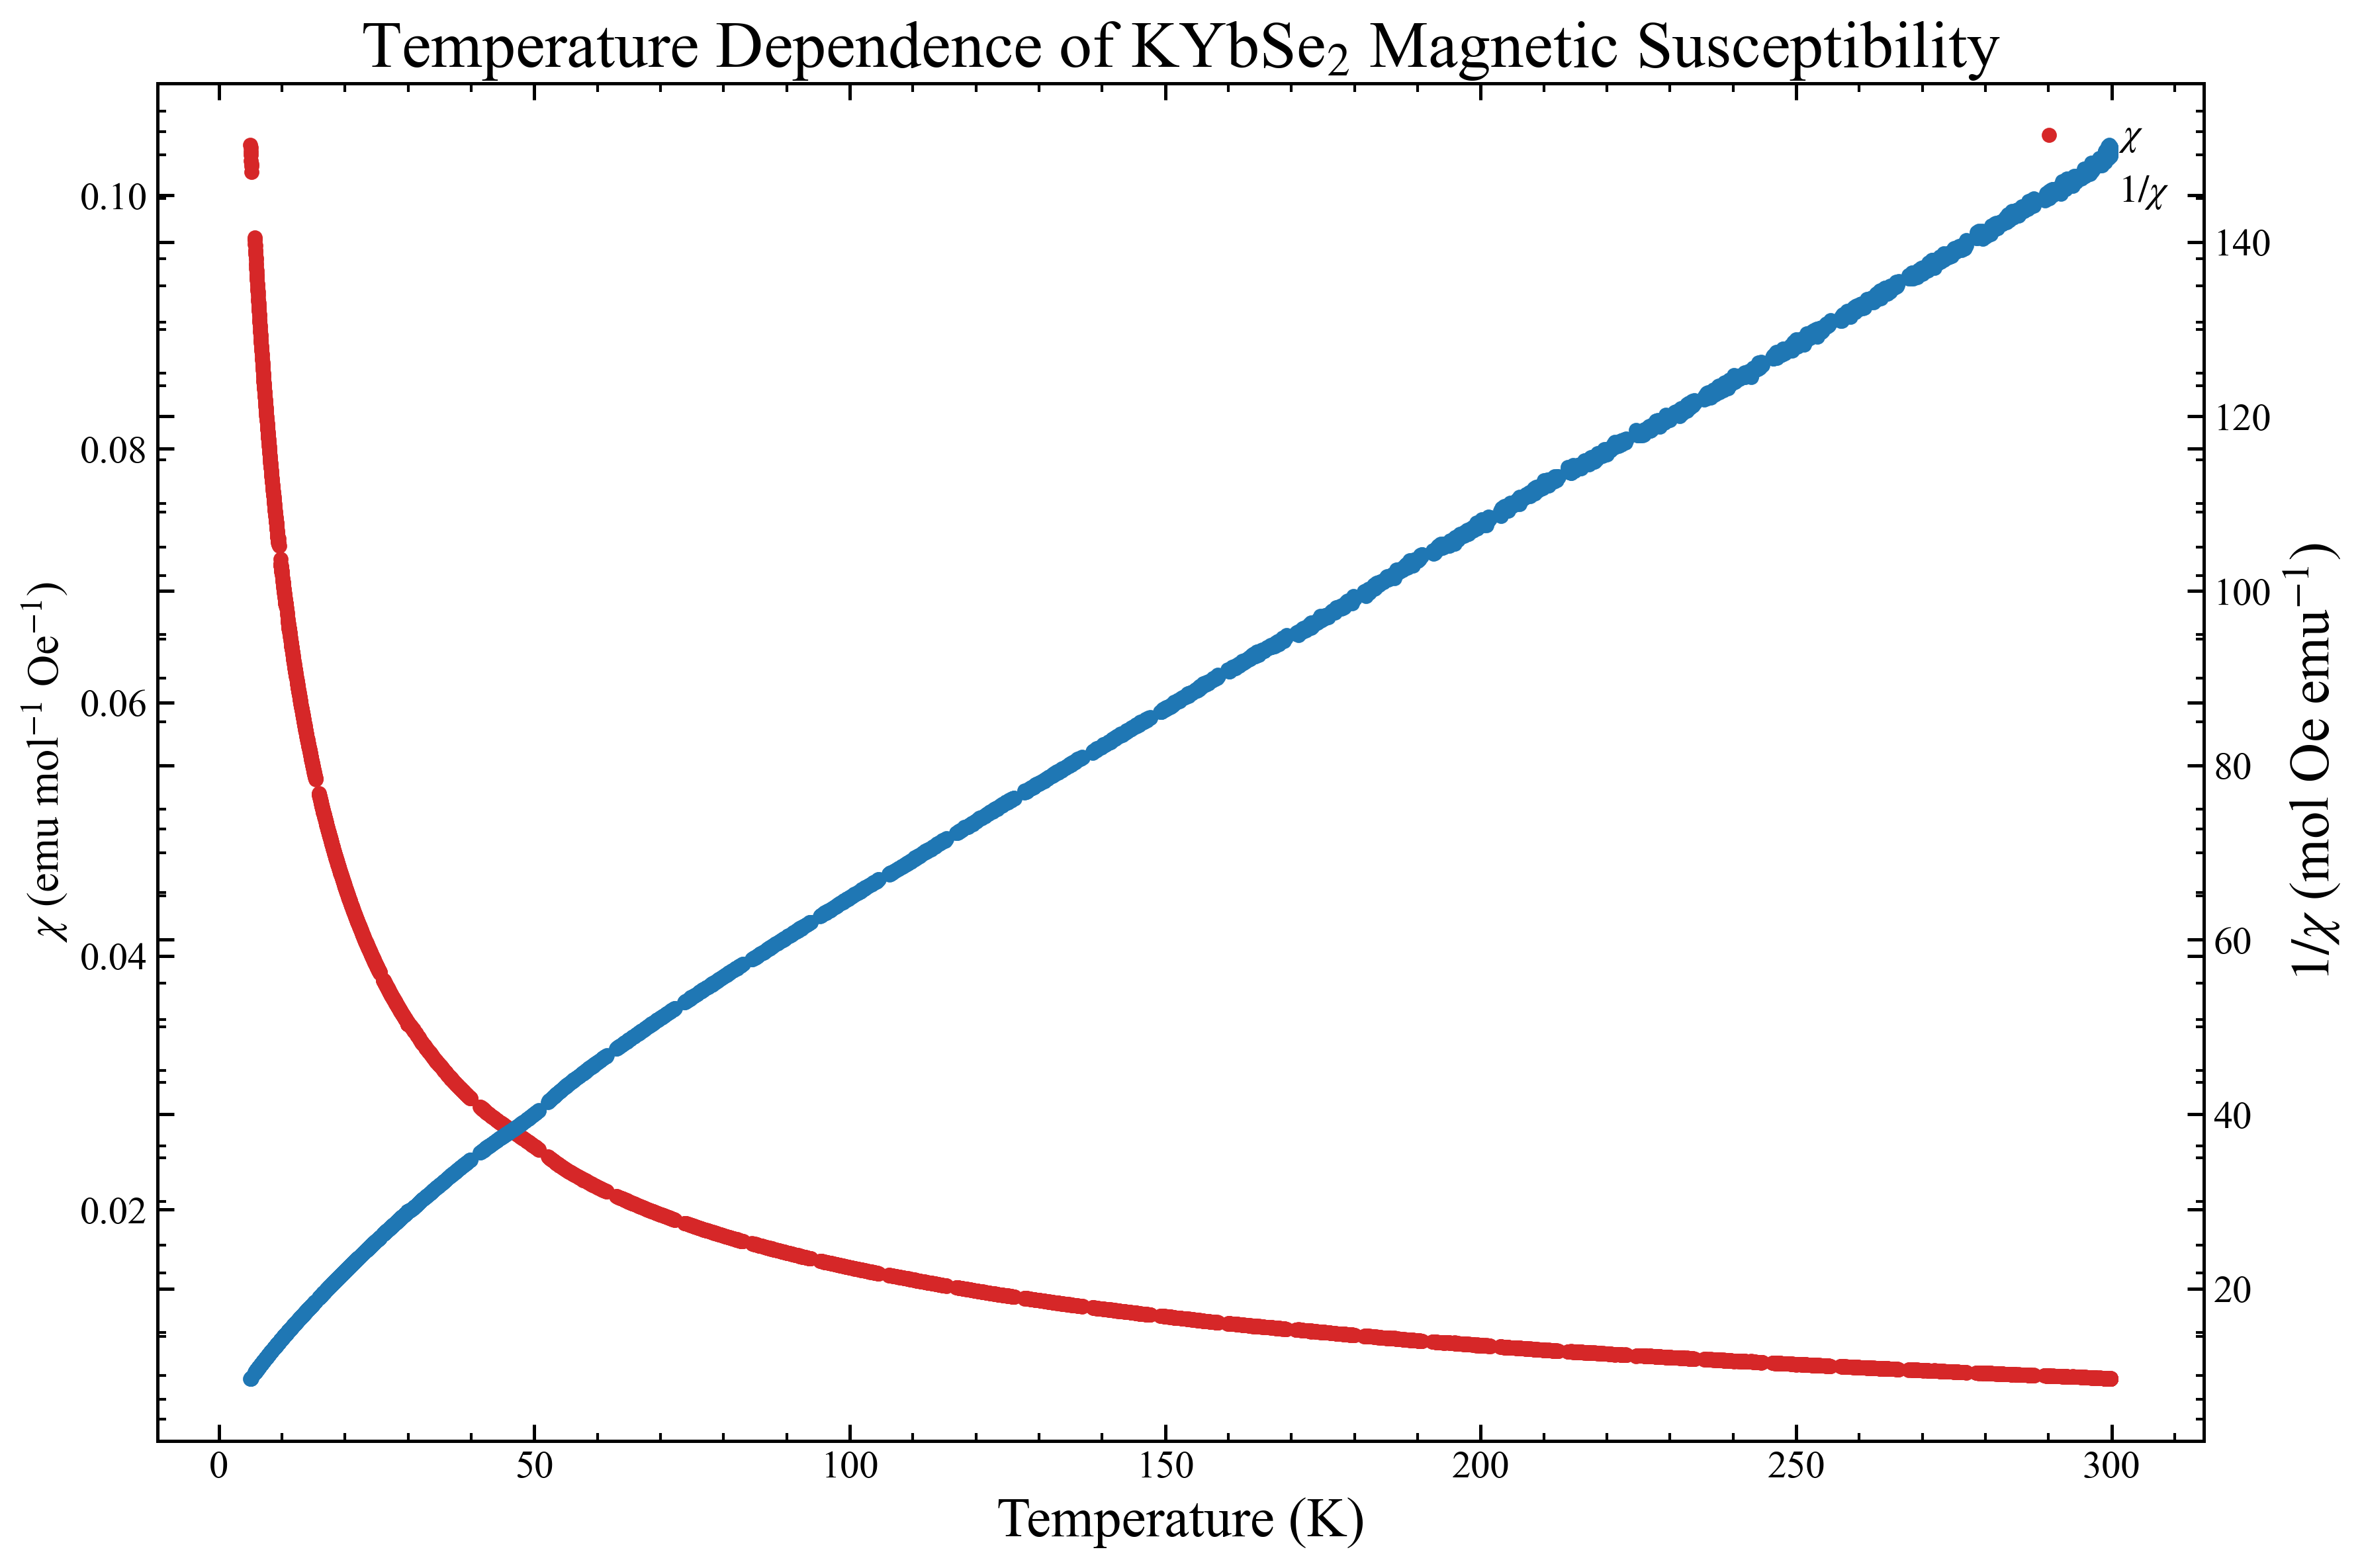

In [44]:
#SUSCEPTIBILITY AND 1/SUSCEPTIBILITY ON ONE PLOT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl

# -----------------------------
# Plot style
# -----------------------------
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'   # makes math fonts match Times

'''
# -----------------------------
# Load reference (Namba) data
# -----------------------------
df_ref = pd.read_csv(
    "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/RuCl3/Data/Magnetisation/Namba_raw_data.csv",
    sep=",", encoding="unicode_escape"
)

x1 = df_ref['x']
y1 = df_ref[' y']   # already emu/mol (not scaled)
'''

# -----------------------------
# Load your data
# -----------------------------
#Filepath where the point the test datafile exists in so it can be accessed
'''MAGNETISATION DATA'''
filepath = "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/KYbSe2/Magnetisation/"
file1 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_FCC_300TO30K.dat"
FILEANDPATHMag1=filepath+file1





file1 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_5KTO30K.dat"
file2 = "KYBSE2_TB001X4_0P2T_HPARA_AB_290526_30K_TO300K.dat"

FILE1 = filepath + file1
FILE2 = filepath + file2

# -----------------------------
# Load datasets for stitching together 5 to 30 k and 30 to 300 K
# -----------------------------
df1, header1 = load_magnetisation_data(
    file_location=FILE1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

df2, header2 = load_magnetisation_data(
    file_location=FILE2,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

# -----------------------------
# Stitch datasets together
# -----------------------------
df = pd.concat([df1, df2], ignore_index=True)

# -----------------------------
# Clean + sort (important for physics plots)
# -----------------------------
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Temperature (K)", "Moment (emu)"])

df = df.sort_values("Temperature (K)").reset_index(drop=True)

# -----------------------------
# Extract variables
# -----------------------------
x2 = df["Temperature (K)"]
M = df["Moment (emu)"]
H = df["Magnetic Field (Oe)"]


df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

# -----------------------------
# Conversion Factor
# -----------------------------
sample_mass = 0.0049  # g
molar_mass = 370.0853 # g/mol
H = df["Magnetic Field (Oe)"]

chi = M / H
y2 = chi * molar_mass / sample_mass

print("x2 length:", len(x2))
print("y2 length:", len(y2))
print("finite y2:", np.isfinite(y2).sum())


# -----------------------------
# Plot χ(T) and χ⁻¹(T)
# -----------------------------
inv_y2 = 1.0 / y2

fig, ax1 = plt.subplots(figsize=(12, 8), dpi=300)
ax2 = ax1.twinx()

# χ(T)
ax1.scatter(
    x2, y2,
    s=20,
    color='tab:red',
    label=r'$\chi$'
)

# χ⁻¹(T)
ax2.scatter(
    x2, inv_y2,
    s=20,
    color='tab:blue',
    label=r'$1/\chi$'
)

# Labels
ax1.set_xlabel("Temperature (K)", fontsize=20)

ax1.set_ylabel(
    r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)",
    fontsize=16
)

ax2.set_ylabel(
    r"$1/\chi$ (mol Oe emu$^{-1}$)",
    fontsize=20
)

ax1.set_title(
    r"Temperature Dependence of KYbSe$_2$ Magnetic Susceptibility",
    fontsize=24
)

# -----------------------------
# Tick styling
# -----------------------------
for ax in [ax1, ax2]:

    ax.tick_params(
        axis='both',
        which='major',
        direction='in',
        top=True,
        bottom=True,
        left=True,
        right=True,
        length=6,
        width=1.2,
        labelsize=14,
        colors='black'
    )

    ax.tick_params(
        axis='both',
        which='minor',
        direction='in',
        top=True,
        bottom=True,
        left=True,
        right=True,
        length=3,
        width=1.0,
        colors='black'
    )

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

# Optional: thicker frame
for spine in ax1.spines.values():
    spine.set_linewidth(1.2)

for spine in ax2.spines.values():
    spine.set_linewidth(1.2)

# Legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='best',
    frameon=False,
    fontsize=14
)

plt.tight_layout()
plt.show()